# 多层全连接网络
在本练习中，你将实现一个具有任意数量隐藏层的全连接网络。
<details><summary>原文</summary>
# Multi-Layer Fully Connected Network
In this exercise, you will implement a fully connected network with an arbitrary number of hidden layers.
</details>

阅读 `cs231n/classifiers/fc_net.py` 文件中的 `FullyConnectedNet` 类。

实现网络的初始化、前向传播和反向传播。在本次作业中，你将在 `cs231n/layers.py` 文件中实现各层。你可以复用之前实现的 `affine_forward`、`affine_backward`、`relu_forward`、`relu_backward` 和 `softmax_loss`。目前不用担心实现 dropout 或批归一化/层归一化，这些功能稍后会添加。
<details><summary>原文</summary>
Read through the `FullyConnectedNet` class in the file `cs231n/classifiers/fc_net.py`.

Implement the network initialization, forward pass, and backward pass. Throughout this assignment, you will be implementing layers in `cs231n/layers.py`. You can re-use your implementations for `affine_forward`, `affine_backward`, `relu_forward`, `relu_backward`, and `softmax_loss` from before. For right now, don't worry about implementing dropout or batch/layer normalization yet, as you will add those features later.
</details>

In [2]:
# 设置环境。
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """返回相对误差。"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [3]:
# 加载（预处理后的）CIFAR-10 数据。
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## 初始损失和梯度检查

作为健壮性检查，运行以下内容以检查初始损失，并对网络在有无正则化的情况下进行梯度检查。这是判断初始损失是否合理的好方法。

对于梯度检查，你应该期望误差在 1e-7 或更小。
<details><summary>原文</summary>
## Initial Loss and Gradient Check

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization. This is a good way to see if the initial losses seem reasonable.

For gradient checking, you should expect to see errors around 1e-7 or less.
</details>

In [4]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C, reg=reg, weight_scale=5e-2, dtype=np.float64)

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # 大多数误差应该在 e-7 或更小的量级。
    # 注意：当 reg = 0.0 时，W2 的误差在 e-5 量级也是可以接受的。
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.300479089768492
W1 relative error: 1.0252674471656573e-07
W2 relative error: 2.2120479295080622e-05
W3 relative error: 4.5623278736665505e-07
b1 relative error: 4.6600944653202505e-09
b2 relative error: 2.085654276112763e-09
b3 relative error: 1.689724888469736e-10
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 1.409028728052923e-08
W2 relative error: 6.86942277940646e-08
W3 relative error: 2.131129859578198e-08
b1 relative error: 1.4752427965311745e-08
b2 relative error: 1.7223751746766738e-09
b3 relative error: 2.378772438198909e-10


作为另一个健壮性检查，确保你的网络能在 50 张图片的小数据集上过拟合。首先，我们将尝试一个每个隐藏层有 100 个单元的三层网络。在下面的代码块中，通过调整**学习率**和**权重初始化尺度**来实现过拟合，并在 20 个 epoch 内达到 100% 的训练准确率。
<details><summary>原文</summary>
As another sanity check, make sure your network can overfit on a small dataset of 50 images. First, we will try a three-layer network with 100 units in each hidden layer. In the following cell, tweak the **learning rate** and **weight initialization scale** to overfit and achieve 100% training accuracy within 20 epochs.
</details>

(Iteration 1 / 40) loss: 2.363364
(Epoch 0 / 20) train acc: 0.180000; val_acc: 0.108000
(Epoch 1 / 20) train acc: 0.320000; val_acc: 0.127000
(Epoch 2 / 20) train acc: 0.440000; val_acc: 0.172000
(Epoch 3 / 20) train acc: 0.500000; val_acc: 0.184000
(Epoch 4 / 20) train acc: 0.540000; val_acc: 0.181000
(Epoch 5 / 20) train acc: 0.740000; val_acc: 0.190000
(Iteration 11 / 40) loss: 0.839976
(Epoch 6 / 20) train acc: 0.740000; val_acc: 0.187000
(Epoch 7 / 20) train acc: 0.740000; val_acc: 0.183000
(Epoch 8 / 20) train acc: 0.820000; val_acc: 0.177000
(Epoch 9 / 20) train acc: 0.860000; val_acc: 0.200000
(Epoch 10 / 20) train acc: 0.920000; val_acc: 0.191000
(Iteration 21 / 40) loss: 0.337174
(Epoch 11 / 20) train acc: 0.960000; val_acc: 0.189000
(Epoch 12 / 20) train acc: 0.940000; val_acc: 0.180000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.199000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.199000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.195000
(Iteration 31 / 40) loss: 

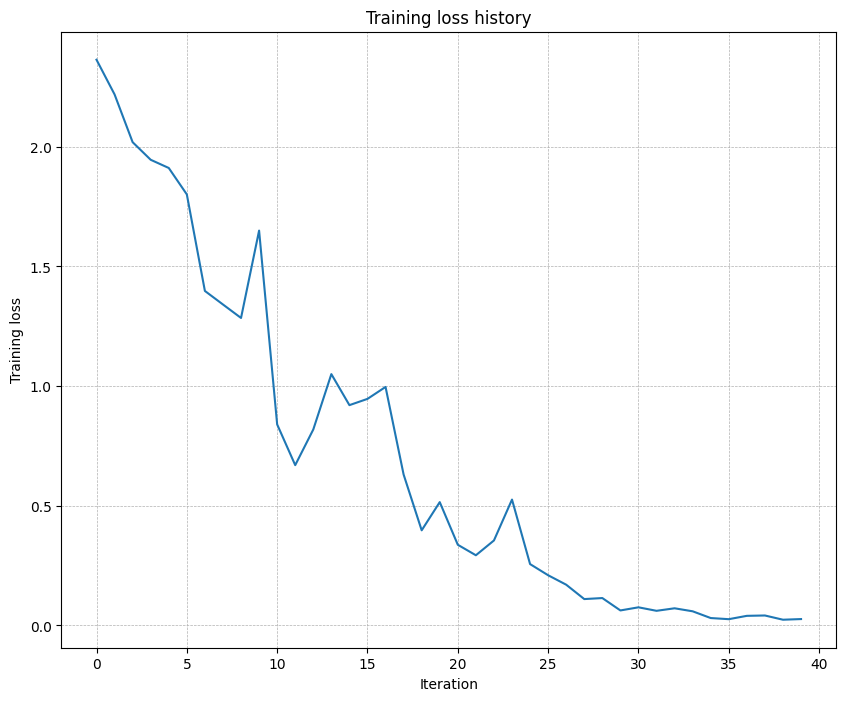

In [5]:
# TODO: 使用三层网络，通过调整学习率和初始化尺度，在 50 个训练样本上实现过拟合。
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
    "X_train": data["X_train"][:num_train],
    "y_train": data["y_train"][:num_train],
    "X_val": data["X_val"],
    "y_val": data["y_val"],
}

weight_scale = 1e-2  # Experiment with this!
learning_rate = 1e-2  # Experiment with this!


model = FullyConnectedNet([100, 100], weight_scale=weight_scale, dtype=np.float64)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(linestyle="--", linewidth=0.5)
plt.show()

现在，尝试使用一个每层 100 个单元的五层网络在 50 个训练样本上过拟合。同样，你需要调整学习率和权重初始化尺度，但你应该能在 20 个 epoch 内达到 100% 的训练准确率。
<details><summary>原文</summary>
Now, try to use a five-layer network with 100 units on each layer to overfit on 50 training examples. Again, you will have to adjust the learning rate and weight initialization scale, but you should be able to achieve 100% training accuracy within 20 epochs.
</details>

(Iteration 1 / 40) loss: 28.032018
(Epoch 0 / 20) train acc: 0.180000; val_acc: 0.121000
(Epoch 1 / 20) train acc: 0.200000; val_acc: 0.088000
(Epoch 2 / 20) train acc: 0.260000; val_acc: 0.134000
(Epoch 3 / 20) train acc: 0.460000; val_acc: 0.119000
(Epoch 4 / 20) train acc: 0.660000; val_acc: 0.124000
(Epoch 5 / 20) train acc: 0.720000; val_acc: 0.113000
(Iteration 11 / 40) loss: 1.463596
(Epoch 6 / 20) train acc: 0.820000; val_acc: 0.120000
(Epoch 7 / 20) train acc: 0.880000; val_acc: 0.127000
(Epoch 8 / 20) train acc: 0.900000; val_acc: 0.125000
(Epoch 9 / 20) train acc: 0.960000; val_acc: 0.128000
(Epoch 10 / 20) train acc: 0.960000; val_acc: 0.124000
(Iteration 21 / 40) loss: 0.083808
(Epoch 11 / 20) train acc: 0.980000; val_acc: 0.120000
(Epoch 12 / 20) train acc: 0.980000; val_acc: 0.128000
(Epoch 13 / 20) train acc: 0.980000; val_acc: 0.134000
(Epoch 14 / 20) train acc: 0.980000; val_acc: 0.129000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.130000
(Iteration 31 / 40) loss:

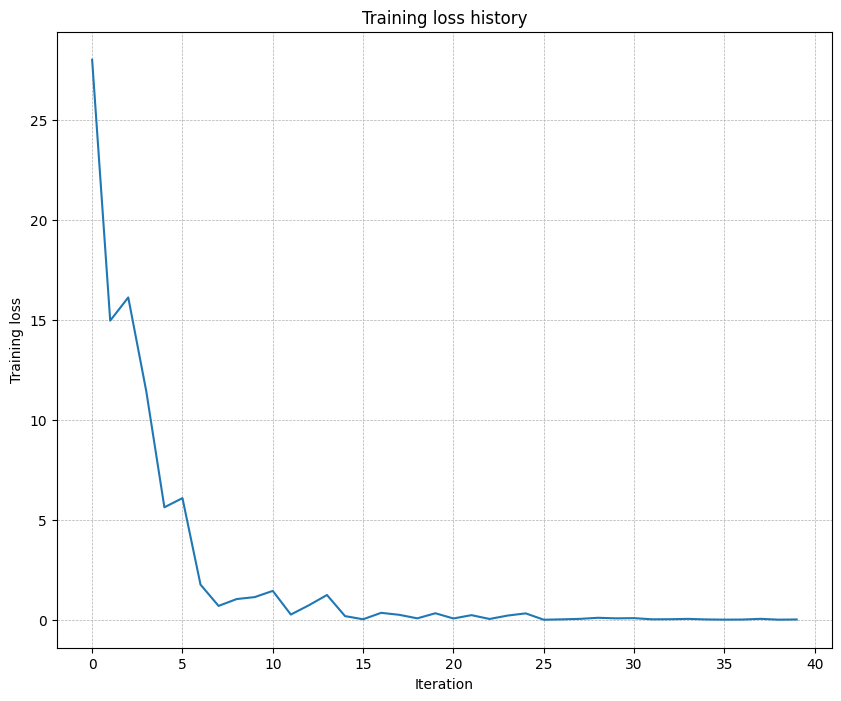

In [6]:
# TODO: 使用五层网络，通过调整学习率和初始化尺度，在 50 个训练样本上实现过拟合。
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
    "X_train": data["X_train"][:num_train],
    "y_train": data["y_train"][:num_train],
    "X_val": data["X_val"],
    "y_val": data["y_val"],
}

learning_rate = 1e-3  # Experiment with this!
weight_scale = 7e-2  # Experiment with this!


model = FullyConnectedNet([100, 100, 100, 100], weight_scale=weight_scale, dtype=np.float64)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(linestyle="--", linewidth=0.5)
plt.show()

## 问题 1：
你是否注意到训练三层网络与五层网络的难度有何不同？特别是根据你的经验，哪个网络对初始化尺度更敏感？你认为原因是什么？

## 答案：
训练五层更难，更深的网络对初始化尺度更敏感，因为权重是根据网络层数连乘的，如果初始化权重小，经过多层连乘后，到后面就快变成0了，如果初始化权重大，到后面就会溢出。
<details><summary>原文</summary>
## Inline Question 1:
Did you notice anything about the comparative difficulty of training the three-layer network vs. training the five-layer network? In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?

## Answer:
[FILL THIS IN]
</details>

# 更新规则
到目前为止，我们一直使用普通的随机梯度下降（SGD）作为更新规则。更复杂的更新规则可以让深度网络更容易训练。我们将实现几种常用的更新规则，并与普通 SGD 进行比较。
<details><summary>原文</summary>
# Update rules
So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks. We will implement a few of the most commonly used update rules and compare them to vanilla SGD.
</details>

## SGD+Momentum
带动量的随机梯度下降（SGD+momentum）是一种广泛使用的更新规则，通常比普通 SGD 收敛更快。更多信息请参见 http://cs231n.github.io/neural-networks-3/#sgd 的 Momentum Update 部分。

打开 `cs231n/optim.py` 文件，阅读顶部的文档以确保你理解 API。在 `sgd_momentum` 函数中实现 SGD+momentum 更新规则，并运行以下代码检查你的实现。你应该看到误差小于 e-8。
<details><summary>原文</summary>
## SGD+Momentum
Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent. See the Momentum Update section at http://cs231n.github.io/neural-networks-3/#sgd for more information.

Open the file `cs231n/optim.py` and read the documentation at the top of the file to make sure you understand the API. Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.
</details>

In [7]:
from cs231n.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


完成后，运行以下代码，用 SGD 和 SGD+momentum 训练一个六层网络。你应该能看到 SGD+momentum 收敛更快。
<details><summary>原文</summary>
Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.
</details>

Running with  sgd
(Iteration 1 / 200) loss: 2.559978
(Epoch 0 / 5) train acc: 0.104000; val_acc: 0.107000
(Iteration 11 / 200) loss: 2.356070
(Iteration 21 / 200) loss: 2.214091
(Iteration 31 / 200) loss: 2.205928
(Epoch 1 / 5) train acc: 0.225000; val_acc: 0.193000
(Iteration 41 / 200) loss: 2.132095
(Iteration 51 / 200) loss: 2.118950
(Iteration 61 / 200) loss: 2.116443
(Iteration 71 / 200) loss: 2.132549
(Epoch 2 / 5) train acc: 0.298000; val_acc: 0.260000
(Iteration 81 / 200) loss: 1.977227
(Iteration 91 / 200) loss: 2.007528
(Iteration 101 / 200) loss: 2.004762
(Iteration 111 / 200) loss: 1.885342
(Epoch 3 / 5) train acc: 0.343000; val_acc: 0.287000
(Iteration 121 / 200) loss: 1.891517
(Iteration 131 / 200) loss: 1.923677
(Iteration 141 / 200) loss: 1.957743
(Iteration 151 / 200) loss: 1.966736
(Epoch 4 / 5) train acc: 0.322000; val_acc: 0.305000
(Iteration 161 / 200) loss: 1.801483
(Iteration 171 / 200) loss: 1.973780
(Iteration 181 / 200) loss: 1.666573
(Iteration 191 / 200) los

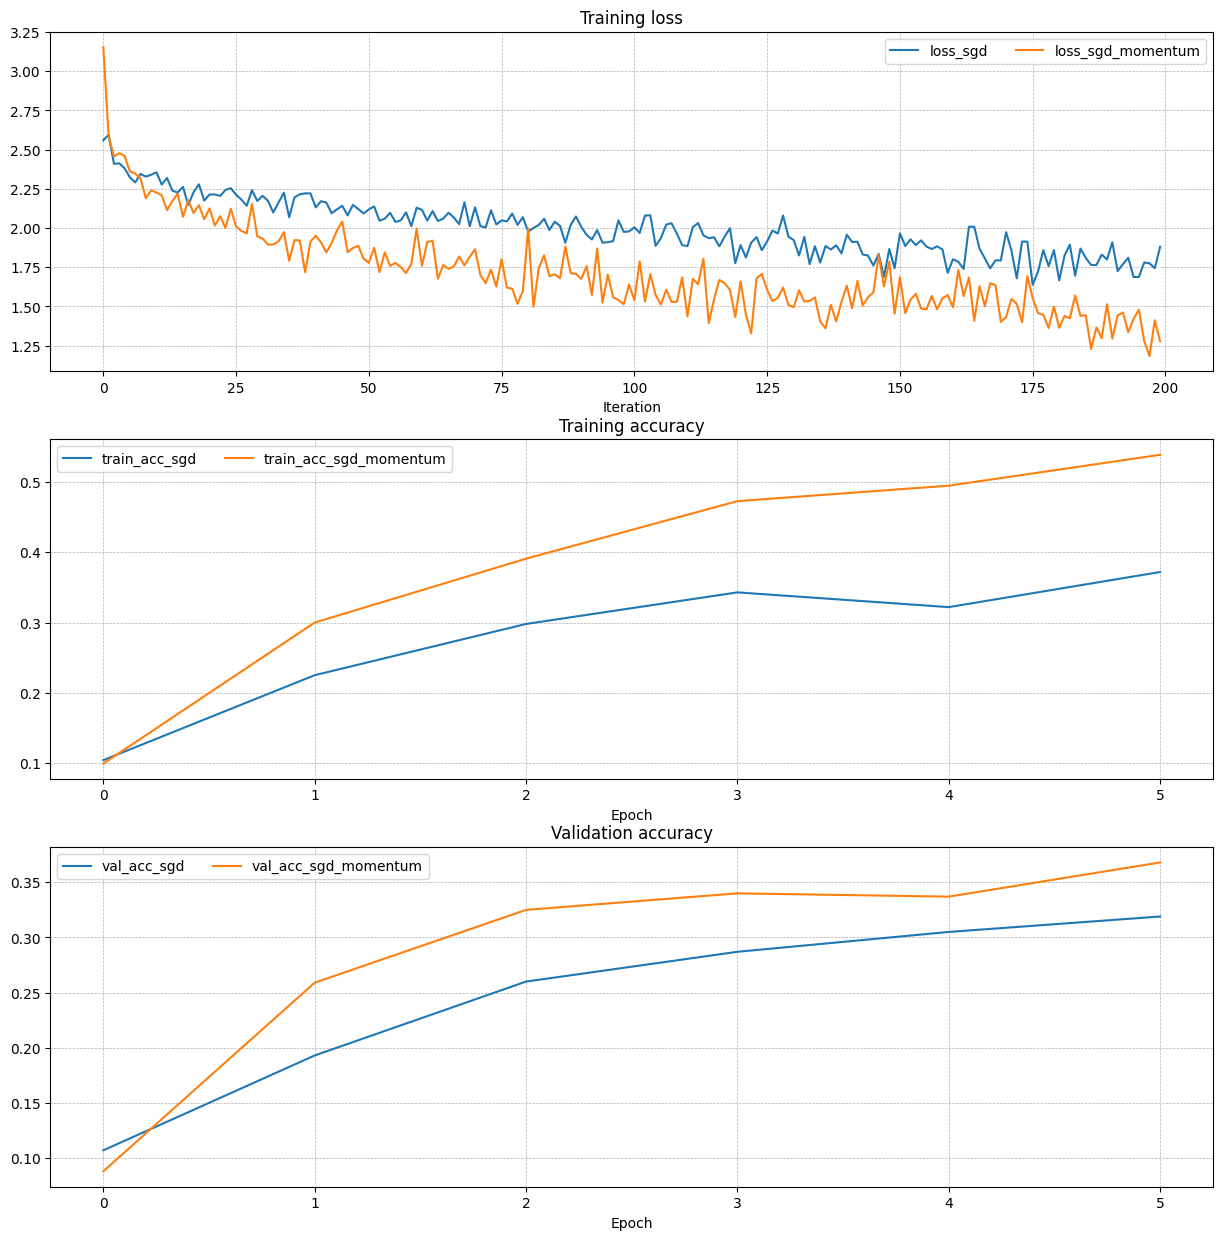

In [8]:
num_train = 4000
small_data = {
    "X_train": data["X_train"][:num_train],
    "y_train": data["y_train"][:num_train],
    "X_val": data["X_val"],
    "y_val": data["y_val"],
}

solvers = {}

for update_rule in ["sgd", "sgd_momentum"]:
    print("Running with ", update_rule)
    model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={"learning_rate": 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title("Training loss")
axes[0].set_xlabel("Iteration")
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[2].set_title("Validation accuracy")
axes[2].set_xlabel("Epoch")

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle="--", linewidth=0.5)

plt.show()

## RMSProp 和 Adam
RMSProp [1] 和 Adam [2] 是通过使用梯度二阶矩的滑动平均来为每个参数设置学习率的更新规则。

在 `cs231n/optim.py` 文件中，实现 `rmsprop` 函数中的 RMSProp 更新规则，以及 `adam` 函数中的 Adam 更新规则，并使用下面的测试检查你的实现。

**注意：** 请实现 Adam 的完整更新规则（包括偏差修正机制），而不是课程笔记中提到的第一个简化版本。

[1] Tijmen Tieleman 和 Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma 和 Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.
<details><summary>原文</summary>
## RMSProp and Adam
RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.

In the file `cs231n/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.
</details>

In [9]:
# 测试 RMSProp 实现
from cs231n.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [10]:
# 测试 Adam 实现
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


调试好 RMSProp 和 Adam 实现后，运行以下代码，使用这些新更新规则训练一对深度网络：
<details><summary>原文</summary>
Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:
</details>

Running with  adam
(Iteration 1 / 200) loss: 3.476928
(Epoch 0 / 5) train acc: 0.126000; val_acc: 0.110000
(Iteration 11 / 200) loss: 2.027712
(Iteration 21 / 200) loss: 2.183357
(Iteration 31 / 200) loss: 1.744257
(Epoch 1 / 5) train acc: 0.363000; val_acc: 0.330000
(Iteration 41 / 200) loss: 1.707951
(Iteration 51 / 200) loss: 1.703835
(Iteration 61 / 200) loss: 2.094758
(Iteration 71 / 200) loss: 1.505558
(Epoch 2 / 5) train acc: 0.419000; val_acc: 0.362000
(Iteration 81 / 200) loss: 1.594429
(Iteration 91 / 200) loss: 1.519016
(Iteration 101 / 200) loss: 1.368523
(Iteration 111 / 200) loss: 1.470400
(Epoch 3 / 5) train acc: 0.460000; val_acc: 0.378000
(Iteration 121 / 200) loss: 1.199064
(Iteration 131 / 200) loss: 1.464705
(Iteration 141 / 200) loss: 1.359863
(Iteration 151 / 200) loss: 1.415122
(Epoch 4 / 5) train acc: 0.522000; val_acc: 0.373000
(Iteration 161 / 200) loss: 1.382401
(Iteration 171 / 200) loss: 1.354979
(Iteration 181 / 200) loss: 1.080265
(Iteration 191 / 200) lo

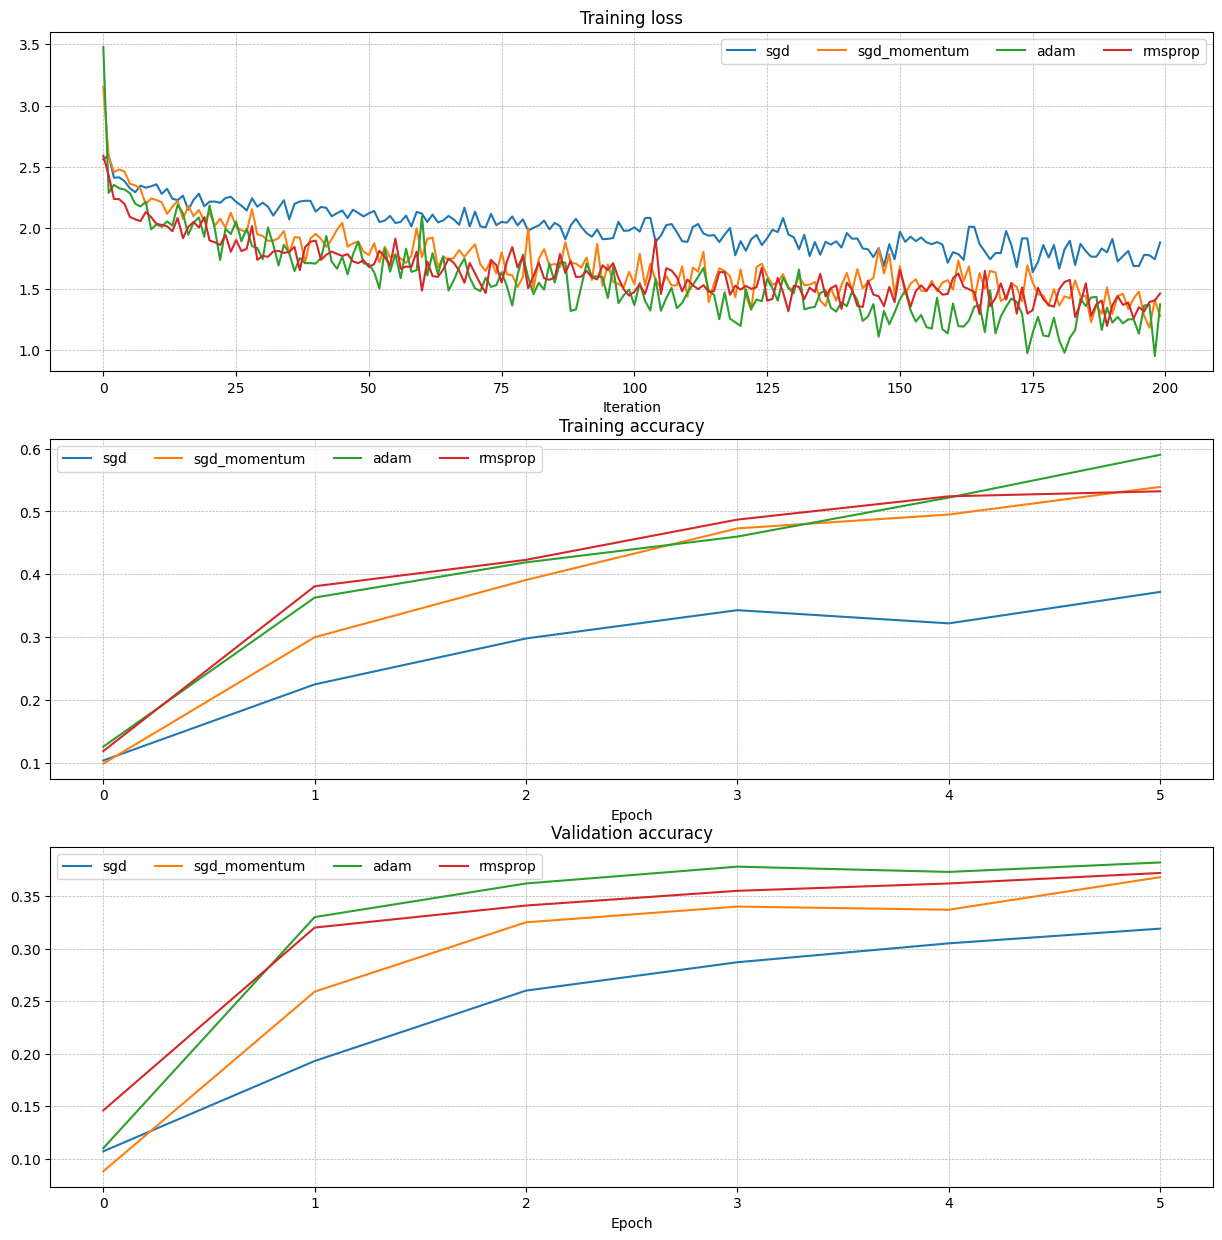

In [11]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## 问题 2：

AdaGrad，和 Adam 一样，是一种每参数优化方法，其更新规则如下：

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John 发现当他用 AdaGrad 训练网络时，更新变得非常小，网络学习变慢。根据你对 AdaGrad 更新规则的理解，你认为为什么更新会变得很小？Adam 会有同样的问题吗？

## 答案：
因为AdaGrad的梯度平方是一直叠加的，没有引入衰减率，所以会越来越大，导致学习率到后面会变为0。Adam不会，因为会遗忘很久之前的旧梯度，只反映近期梯度。
<details><summary>原文</summary>
## Inline Question 2:

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John notices that when he was training a network with AdaGrad that the updates became very small, and that his network was learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?

## Answer:
[FILL THIS IN]
</details>

# 训练一个好模型！
在 CIFAR-10 上训练你能得到的最好的全连接模型，并将其存储在 `best_model` 变量中。我们要求你使用全连接网络在验证集上至少达到 50% 的准确率。

如果你足够仔细，准确率可以超过 55%，但本部分不要求更高分数，也不会有额外加分。下一次作业我们会让你在 CIFAR-10 上训练最好的卷积网络，我们更希望你把精力放在卷积网络上。

**注意：** 在下一次作业中，你将学习如 BatchNormalization 和 Dropout 等技术，这些可以帮助你训练更强大的模型。
<details><summary>原文</summary>
# Train a Good Model!
Train the best fully connected model that you can on CIFAR-10, storing your best model in the `best_model` variable. We require you to get at least 50% accuracy on the validation set using a fully connected network.

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so. Later in the next assignment, we will ask you to train the best convolutional network that you can on CIFAR-10, and we would prefer that you spend your effort working on convolutional networks rather than fully connected networks.

**Note:** In the next assignment, you will learn techniques like BatchNormalization and Dropout which can help you train powerful models.
</details>

In [12]:
best_model = None

################################################################################
# TODO: 训练你能得到的最好的 FullyConnectedNet，并将其存储在 best_model 变量中。你可以使用批归一化/层归一化和 dropout。 #
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****你的代码开始（请勿删除/修改此行）*****
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
hidden_dims = [150, 150, 150]  
weight_scale = 5e-2 
learning_rate = 1e-3
reg = 5e-4

model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, reg=reg)

solver = Solver(
    model, 
    data,                  
    num_epochs=12, 
    batch_size=200,
    update_rule='adam',    
    optim_config={
        'learning_rate': learning_rate
    },
    lr_decay=0.95,
    verbose=True,          
    print_every=100        
)

solver.train()

best_model = model

# *****你的代码结束（请勿删除/修改此行）*****
# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                              代码结束                                         #
#                              END OF YOUR CODE                                #
################################################################################

(Iteration 1 / 2940) loss: 22.667950
(Epoch 0 / 12) train acc: 0.130000; val_acc: 0.146000
(Iteration 101 / 2940) loss: 2.276463
(Iteration 201 / 2940) loss: 2.010189
(Epoch 1 / 12) train acc: 0.403000; val_acc: 0.366000
(Iteration 301 / 2940) loss: 1.799557
(Iteration 401 / 2940) loss: 1.883817
(Epoch 2 / 12) train acc: 0.477000; val_acc: 0.432000
(Iteration 501 / 2940) loss: 1.786737
(Iteration 601 / 2940) loss: 1.852309
(Iteration 701 / 2940) loss: 1.709693
(Epoch 3 / 12) train acc: 0.474000; val_acc: 0.437000
(Iteration 801 / 2940) loss: 1.720643
(Iteration 901 / 2940) loss: 1.574131
(Epoch 4 / 12) train acc: 0.531000; val_acc: 0.479000
(Iteration 1001 / 2940) loss: 1.611416
(Iteration 1101 / 2940) loss: 1.337022
(Iteration 1201 / 2940) loss: 1.701068
(Epoch 5 / 12) train acc: 0.557000; val_acc: 0.476000
(Iteration 1301 / 2940) loss: 1.623862
(Iteration 1401 / 2940) loss: 1.603434
(Epoch 6 / 12) train acc: 0.579000; val_acc: 0.493000
(Iteration 1501 / 2940) loss: 1.436126
(Iteratio

# 测试你的模型！
在验证集和测试集上运行你的最佳模型。你应该在验证集和测试集上都达到至少 50% 的准确率。
<details><summary>原文</summary>
# Test Your Model!
Run your best model on the validation and test sets. You should achieve at least 50% accuracy on the validation set and the test set.
</details>

In [13]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.512
Test set accuracy:  0.503
